In [11]:
import pandas as pd
import numpy as np

In [12]:
# Load the dataset
df = pd.read_csv('Amazon.csv')

In [13]:
df.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
0,2023/06/08 7:50:55 PM GMT+5:30,65,Prefer not to say,Less than once a month,Clothing and Fashion,Yes,Multiple times a day,Keyword,Multiple pages,2,...,Yes,Moderately,No,2,Sometimes,4,4,Competitive prices,better app interface and lower shipping charges,778242
1,2023/06/09 9:37:44 AM GMT+5:30,20,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,No,Rarely,Filter,First page,3,...,Yes,Heavily,Yes,1,Sometimes,4,5,Quick delivery,Scrolling option would be much better than goi...,193482
2,2023/06/11 11:26:54 PM GMT+5:30,42,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,Sometimes,Few times a week,Keyword,Multiple pages,2,...,Yes,Heavily,Sometimes,5,No,5,3,All the above,Nil,925975
3,2023/06/08 5:17:10 PM GMT+5:30,65,Others,Once a month,Beauty and Personal Care;Clothing and Fashion;...,No,Few times a month,Filter,Multiple pages,2,...,Yes,Occasionally,No,3,Yes,1,2,Quick delivery,Quality of product is very poor according to t...,566872
4,2023/06/11 10:59:30 PM GMT+5:30,45,Female,Once a week,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Few times a month,NaN,First page,5,...,Yes,Rarely,No,2,Yes,1,2,Quick delivery,Irrelevant product suggestions,683642


Task 1 : Data Cleaning and Preparation

In [20]:
# 1.1 Remove duplicate or inconsistent survey responses 
df = df.drop_duplicates()

In [21]:
# 1.2 Standardize categorical entries 
# Example: Standardizing Gender and Frequency
df['Gender'] = df['Gender'].str.strip().str.capitalize()
df['Purchase_Frequency'] = df['Purchase_Frequency'].str.lower()

In [22]:
# 1.3 Handle missing values in Product_Search_Method and others 
df['Product_Search_Method'] = df['Product_Search_Method'].fillna('Unknown')
# Dropping rows where essential target data is missing
df.dropna(subset=['Shopping_Satisfaction'], inplace=True)

In [23]:
# 1.4 Rename duplicate or misformatted columns 
# Removing trailing spaces in Rating_Accuracy and handling the duplicate Recommendation column
df.rename(columns={'Rating_Accuracy ': 'Rating_Accuracy'}, inplace=True)
# If a duplicate column exists, we drop the second one
df = df.loc[:, ~df.columns.duplicated()]

In [24]:
# 1.5 Convert numerical rating columns to appropriate numeric types
cols_to_fix = ['Customer_Reviews_Importance', 'Shopping_Satisfaction', 'Rating_Accuracy']
for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [25]:
df.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
0,2023/06/08 7:50:55 PM GMT+5:30,65,Prefer not to say,less than once a month,Clothing and Fashion,Yes,Multiple times a day,Keyword,Multiple pages,2,...,Yes,Moderately,No,2,Sometimes,4,4,Competitive prices,better app interface and lower shipping charges,778242
1,2023/06/09 9:37:44 AM GMT+5:30,20,Male,once a week,Groceries and Gourmet Food;Beauty and Personal...,No,Rarely,Filter,First page,3,...,Yes,Heavily,Yes,1,Sometimes,4,5,Quick delivery,Scrolling option would be much better than goi...,193482
2,2023/06/11 11:26:54 PM GMT+5:30,42,Male,once a week,Groceries and Gourmet Food;Beauty and Personal...,Sometimes,Few times a week,Keyword,Multiple pages,2,...,Yes,Heavily,Sometimes,5,No,5,3,All the above,Nil,925975
3,2023/06/08 5:17:10 PM GMT+5:30,65,Others,once a month,Beauty and Personal Care;Clothing and Fashion;...,No,Few times a month,Filter,Multiple pages,2,...,Yes,Occasionally,No,3,Yes,1,2,Quick delivery,Quality of product is very poor according to t...,566872
4,2023/06/11 10:59:30 PM GMT+5:30,45,Female,once a week,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Few times a month,Unknown,First page,5,...,Yes,Rarely,No,2,Yes,1,2,Quick delivery,Irrelevant product suggestions,683642


Task 2 : Descriptive Behavior Analysis

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
# 2.1 Summarize customer demographics (age, gender distribution) 
print(df['age'].describe())
print(df['Gender'].value_counts())

count    800.000000
mean      35.170000
std       18.916485
min        3.000000
25%       19.000000
50%       35.500000
75%       51.000000
max       67.000000
Name: age, dtype: float64
Gender
Male                 209
Others               202
Female               197
Prefer not to say    192
Name: count, dtype: int64


In [11]:
# 2.2 Analyze purchase frequency and popular categories 
print(df['Purchase_Frequency'].value_counts())
# Assuming categories are comma-separated in the survey
top_categories = df['Purchase_Categories'].str.get_dummies(sep=',').sum().sort_values(ascending=False)
print(top_categories.head(5))

Purchase_Frequency
once a month              168
once a week               159
multiple times a week     159
few times a month         158
less than once a month    156
Name: count, dtype: int64
Clothing and Fashion;others                             39
others                                                  38
Beauty and Personal Care;Clothing and Fashion;others    38
Clothing and Fashion;Home and Kitchen;others            36
Groceries and Gourmet Food;Clothing and Fashion         34
dtype: int64


In [12]:
# 2.3 Top browsing methods and cart abandonment factors 
print(df['Product_Search_Method'].value_counts())
print(df['Cart_Abandonment_Factors'].value_counts())

Product_Search_Method
Keyword       170
categories    163
Filter        161
Unknown       157
others        149
Name: count, dtype: int64
Cart_Abandonment_Factors
High shipping costs                           224
Found a better price elsewhere                206
Changed my mind or no longer need the item    194
others                                        176
Name: count, dtype: int64


In [13]:
# 2.4 Calculate mean/median for satisfaction and accuracy 
metrics = df[['Shopping_Satisfaction', 'Rating_Accuracy']].agg(['mean', 'median'])
print(metrics)

        Shopping_Satisfaction  Rating_Accuracy
mean                   3.0125          2.96875
median                 3.0000          3.00000


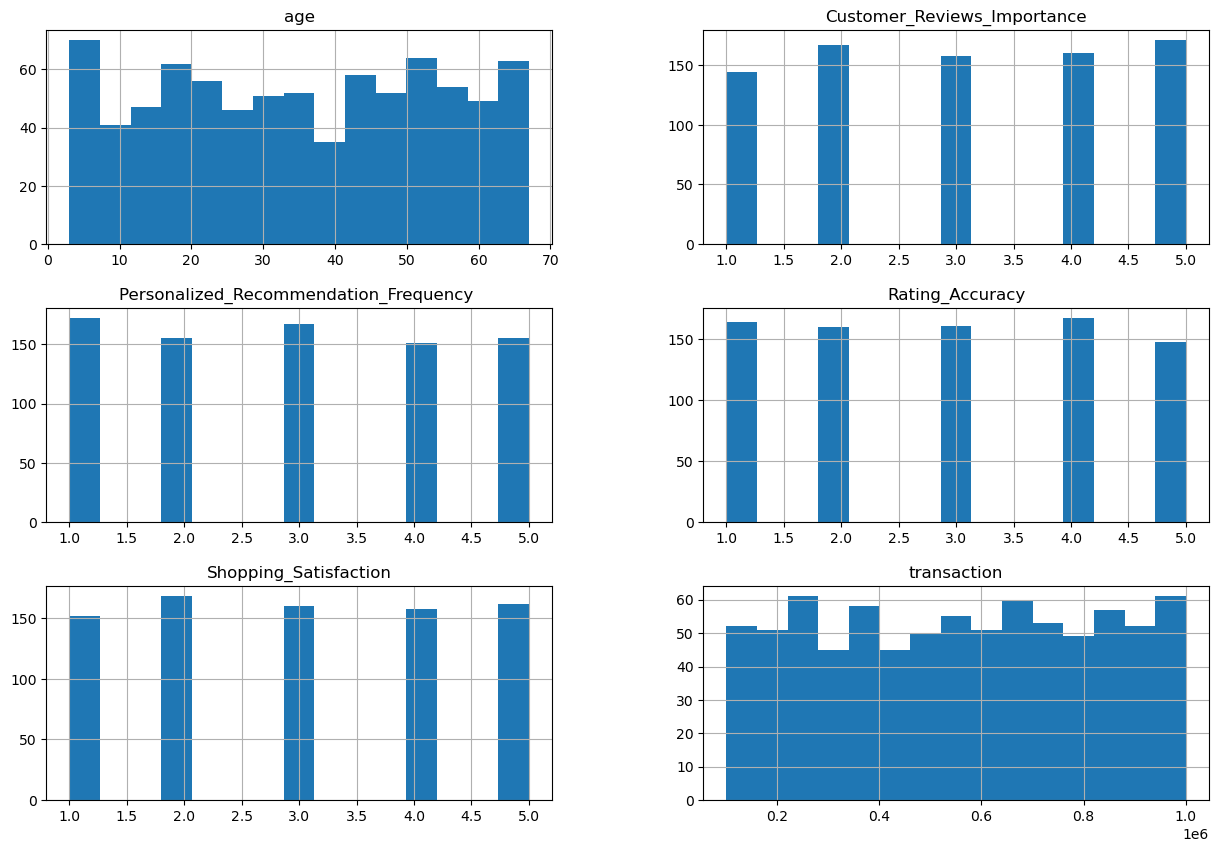

In [14]:
# 2.5 Generate summary statistics and visualizations 
df.hist(bins=15, figsize=(15, 10))
plt.show()

Task 3: Customer Segmentation and Profiling

In [15]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [16]:
# 3.1 & 3.5 Use clustering (K-Means) for behavioral grouping 
# Selecting features for segmentation (Frequency and Satisfaction)
# Note: Frequency needs to be encoded numerically first
freq_map = {'few times a week': 4, 'once a month': 2, 'less than once a month': 1}
df['Freq_Score'] = df['Purchase_Frequency'].map(freq_map).fillna(0)

features = df[['Freq_Score', 'Shopping_Satisfaction']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42)
df['Segment'] = kmeans.fit_predict(scaled_features)

In [17]:
# 3.2 - 3.4 Define profiles based on cluster centers 
# Segment 0: Frequent Buyers, Segment 1: Occasional, Segment 2: At-Risk

Task 4 : Recommendation and Review Insights

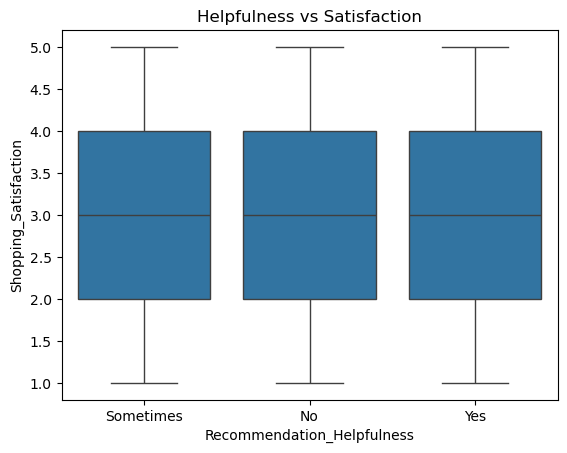

In [18]:
# 4.1 Relationship between recommendation helpfulness and satisfaction [cite: 37]
sns.boxplot(x='Recommendation_Helpfulness', y='Shopping_Satisfaction', data=df)
plt.title('Helpfulness vs Satisfaction')
plt.show()

In [19]:
# Mapping text responses to numerical values for correlation analysis
reliability_map = {
    'Heavily': 3, 
    'Moderately': 2, 
    'Occasionally': 1, 
    'Rarely': 0, 
    'Never': 0
}

# Create a new numerical column based on the mapping
df['Review_Reliability_Num'] = df['Review_Reliability'].map(reliability_map).fillna(0)

# Now calculate the correlation with Rating_Accuracy (which is already numeric from Task 1)
correlation_value = df['Review_Reliability_Num'].corr(df['Rating_Accuracy'])

print(f"Correlation between Review Reliability and Rating Accuracy: {correlation_value:.2f}")

Correlation between Review Reliability and Rating Accuracy: 0.06


In [20]:
# 4.3 Trends in personalized recommendation trust 
trust_trend = df['Personalized_Recommendation_Frequency'].value_counts()
print(trust_trend)

Personalized_Recommendation_Frequency
Yes          278
No           272
Sometimes    250
Name: count, dtype: int64


Task 5: Visualization and Reporting

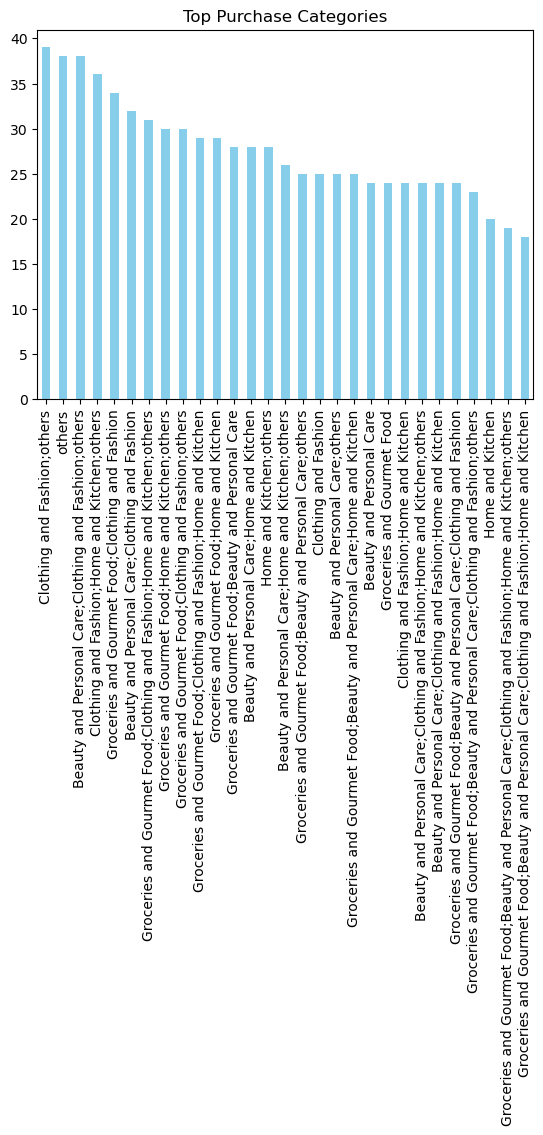

In [21]:
# 5.1 & 5.2 Purchase categories bar chart 
top_categories.plot(kind='bar', color='skyblue')
plt.title('Top Purchase Categories')
plt.show()

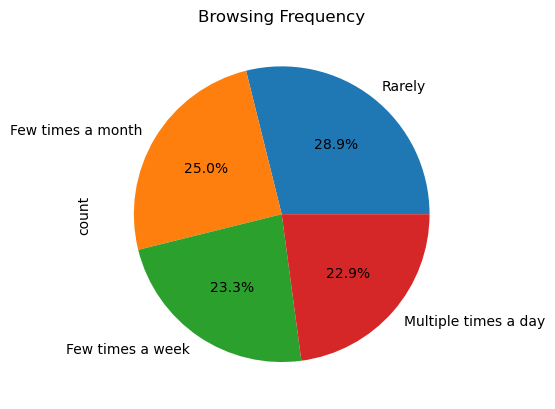

In [22]:
# 5.3 Browsing frequency distribution 
df['Browsing_Frequency'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Browsing Frequency')
plt.show()

C:\Users\sony\AppData\Local\Temp\ipykernel_11944\758878134.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Shopping_Satisfaction', data=df, palette='viridis')


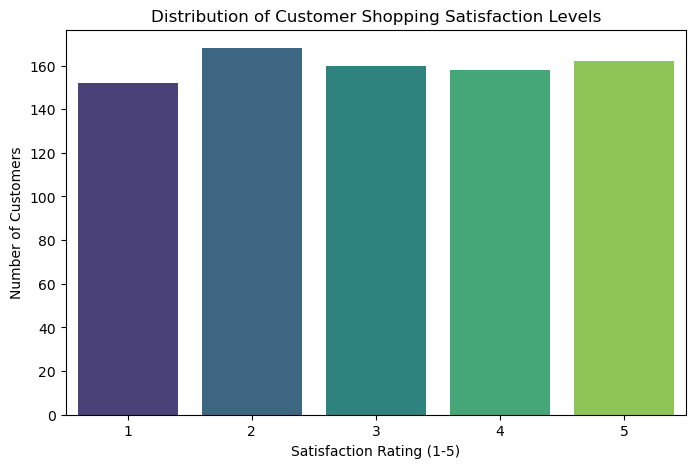

In [23]:
# Task 5.5: Visualization of Satisfaction Levels
plt.figure(figsize=(8, 5))
sns.countplot(x='Shopping_Satisfaction', data=df, palette='viridis')
plt.title('Distribution of Customer Shopping Satisfaction Levels')
plt.xlabel('Satisfaction Rating (1-5)')
plt.ylabel('Number of Customers')
plt.show()

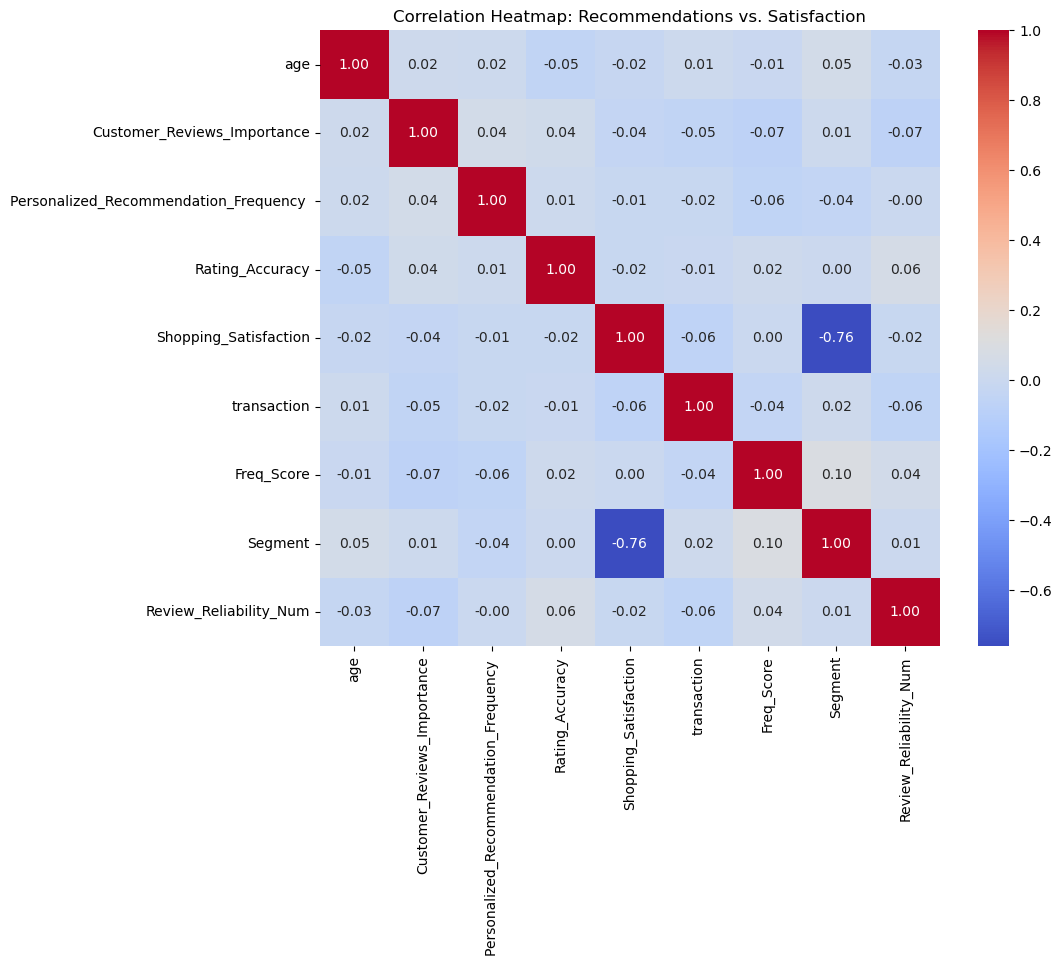

In [24]:
# Task 5.6: Correlation Heatmap
# We select only the numeric columns to avoid the "could not convert string to float" error.
# We include the newly created 'Recommendation_Helpfulness_Num' and 'Shopping_Satisfaction'
numeric_cols = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 8))
# Use numeric_only=True to ensure the function only looks at numbers
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: Recommendations vs. Satisfaction')
plt.show()